In [1]:
import requests
from IPython.core.display import HTML
HTML(f"""
<style>
</style>
""")

# Question 5 c)
Discuss how factors affect a model’s ability to generalize to unseen data. Relate this to concepts of data evaluation, such as train-test splits, cross-validation, and performance metrics, to assess a model’s predictive capability and robustness.

- Generalization -> How effectively the model can predict
- Overfitting and underfitting -> Both affect the ability to generalize
- Underfitting -> Model performs poorly on training and test data
- Overfitting -> Model performs well on training data, but poorly on test data
- Train test split (Task 1 (split data)) -> Splitting the dataset into training and test data
- Train test split (w7-02 Task 3 )
- Train-Validation-test -> Validation data is used to finetune the model 
- Cross-validation - k-fold
- Split into k folds, 1 validation, k-1 training folds.
- We then do training k experiments (with different folds as the validation fold) all leading to different parameters.
- Determine what model has lowest MSE for both training and validation
- Do this for all models you want to test, example up to n-th order polynomial
- Now evaluate final model with test data
- Performance metrics MSE -> Subtract prediction from target, square, penalise large errors (sensitive to outliers)
- Performance metrics RMSE -> Sensitive to outliers, but on the original scale. This can be more intuitive to understand. (task 9)

# Polynomial regression

**Info**
If you're short on time leave this exercise for later and prioritize the next exercises.



In [2]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

In this exercise, suppose you want to buy a house in the City of Windsor, Canada. You contact a real-estate salesperson to get information about current house prices and receive details on 546 properties sold in Windsor in the last two years. You would like to figure out what the expected cost of a house might be given only the lot size of the house you want to buy. The dataset has an independent variable, `lotsize`
, specifying the lot size of a property and a dependent variable, `price`
, the sale price of a house. Assume an $N$th-order polynomial relation between `price`
 and `lot-size`
.
The goal is to estimate the best model (in a least-square-sense) that predicts the house price based from lot size.
You will implement a method to estimate the model parameters of  $N$-th order polynomials and use the model to predict the price of a house (in Canadian dollars) based on its lot size (in square feet).
A polynomial _model_ of order $N$ is defined by:

$$
f_\mathbf{w}(x) = \mathbf{w}_0 + \mathbf{w}_1 x + \mathbf{w}_2 x^2 + \dots + \mathbf{w}_N x^N,
$$
in which, the coefficients $\mathbf{w}_i$ are the model parameters and $x$ is the `lot_size`
. 
**Note:** Note that $f_\mathbf{w}$ is linear in the model parameters, $\mathbf{w}$. Solving for the model parameters can be done by setting up the linear set of equations $A \mathbf{w} = y$.

Where

$$
\underbrace{\begin{bmatrix}
    1 & x_1 & x_1^2 & x_1^3 & \dots & x_1^N \\
    1 & x_2 & x_2^2 & x_2^3 & \dots & x_2^N \\
    1 & x_3 & x_3^2 & x_3^3 & \dots & x_3^N \\
    \vdots & \vdots & \vdots & \vdots & \ddots & \vdots \\
    1 & x_m & x_m^2 & x_m^3 & \dots & x_m^N
\end{bmatrix}}_A
\times
\underbrace{\begin{bmatrix}
    \mathbf{w}_0 \\
    \mathbf{w}_1 \\
    \mathbf{w}_2 \\
    \mathbf{w}_3 \\
    \vdots \\
    \mathbf{w}_N
\end{bmatrix}}_\mathbf{w}
=
\underbrace{\begin{bmatrix}
    y_1 \\
    y_2 \\
    y_3 \\
    \vdots \\
    y_m
\end{bmatrix}}_y.
$$
Define the _loss_ $\mathcal{L}$ for a single prediction as the squared error

$$
\mathcal{L}(\hat{y}_i, y_i) = (\hat{y}_i-y_{i})^2,
$$
where $\hat{y}_i=f_{\mathbf{w}}(x_i)$ is the prediction and $y_i$ is the label.
The linear least squares method minimizes the sum of squares. In other words, the parameters $\mathbf{w}$ can be learned by solving the following optimisation problem:

$$
\mathbf{w} = \underset{\mathbf{w}}{\operatorname{argmin}} \frac{1}{m}\sum_{i=1}^{m} \mathcal{L}(\hat{y}_i, y_i) \quad\quad \text{(1)}
$$
**Note:** Recall projecting the vector of labels $\mathbb{y} = \begin{bmatrix} y_1\\y_2\\\vdots\\y_n \end{bmatrix}$ onto the column space of the design matrix defined by $A$ is equivalent to minimizing the mean squared error in Equation 1.

## Data exploration
The following cell loads the dataset and visualizes the data:


Text(0, 0.5, 'House price')

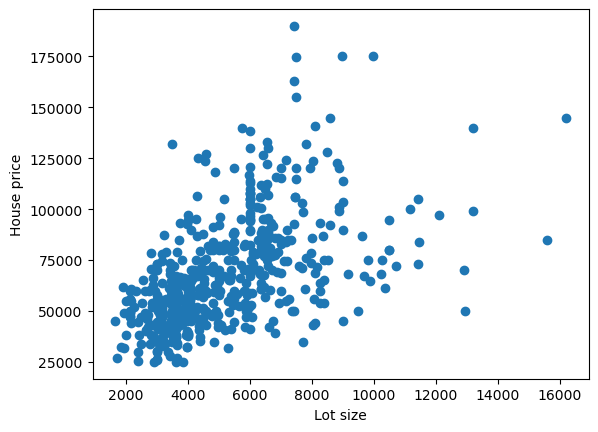

In [3]:
filename = "./data/simple_windsor.csv"
names = ["lotsize", "price"]
dataset = np.loadtxt(filename, delimiter=',').astype(np.int64)

X_full, y_full = dataset.T

plt.scatter(X_full, y_full)
plt.xlabel('Lot size')
plt.ylabel('House price')


---
**Task 1 (easy): Questions💡**
1. In the cell below list and characterize 5 observations about the data.


---

In [4]:
## List reasons here
# The data is very concentrated in the bottom left corner of the plot
# It does not seem to follow a linear regression (there are many y-values for each x-value)
# But there still seems to be a tendency of prices to rise as lot size increases

### Splitting into train and test data
The following cell splits the dataset into $80\%$ training data and $20\%$ test data using the scikit-learn library
:


In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_full, y_full, test_size=0.2, random_state=42)

## Polynomial regression
The following exercise guides you through the steps (1-4) for learning the polynomial model.
1. Define the model, e.g. line or polynomial.
2. Identitfy knowns and uknowns.
3. Identify the kernel.
4. Construct the design matrix $A$ for the dataset (see the `get_design_matrix`
 function below).
5. Estimate the model parameters using linear least squares ( [Task 2](#estimate) ).

The function `get_design_matrix`
 (defined in the cell below) creates a design matrix for a polynomial of order $N$.


In [6]:
def get_design_matrix(x, order=1):
    """
    Get the coefficients of polynomial in a least square sense of order N.
    
    :param x: Must be numpy array of size (N).
    :order n: Order of Polynomial.
    """
    
    if order < 1 or x.ndim != 1:
        return x

    count = x.shape[0]
    matrix = np.ones((count, order + 1), np.float64)

    for i in range(1, order+1):
        matrix[:, i] = x**i

    #print(matrix)

    return matrix


---
**Task 2 (medium): Estimate model parameters👩‍💻**
Implement the function `train(X, y, order)`
 in the cell below to learn the model parameters. Use `get_design_matrix(X, order)`
 to create the design matrix.

---

In [7]:
def train(X, y, order):
    """
    :param X: Input vector.
    :param y: Training data values.
    :param order: Order of the model to estimate.
    
    :return: Parameters of model.
    """
    design_matrix = get_design_matrix(X, order)
    weights,_,_,_ = np.linalg.lstsq(design_matrix, y)
    return weights
    


---
**Task 3 (easy): Define prediction model👩‍💻**
Use the learned model parameters to predict house prices given an input vector $X$ of lot sizes. Implement the prediction function `predict(X, params)`
 in the cell below. 

---

In [8]:
def predict(X, w, order=1):
    """
    :param X: Input vector.
    :param w: Estimated parameters.
    
    :return: Predicted y-values.
    """
    '''pred_y = np.empty(len(X))
    for i in range(len(X)): 
        pred_y[i] = w[0]+w[1]*X[i]+w[2]*(X[i]**2)
    
    return pred_y'''
    
    '''pred_y = np.empty(len(X))
    for i in range(len(X)): 
        pred_y[i] = w[0]
        for j in range(1, order+1):
            pred_y[i] = pred_y[i]+(w[j]*(X[i]**j))
    
    return pred_y'''

    design_matrix = get_design_matrix(X, order)
    return design_matrix@w
    

    


---
**Task 4 (easy): Prediction👩‍💻**
In this task you will use the learnt model parameters for making predictions of house prices given lot sizes. Implement the following steps (marked by `#`
) in the code cell below.
1. Learn model parameters using `X_train`
 and `y_train`
. 
2. In the cell below calculate the predicted house prices (`y`
-values) given the lot-sizes defined in the `values`
 variable.
3. Plot the predicted house prices as a line-plot.


---

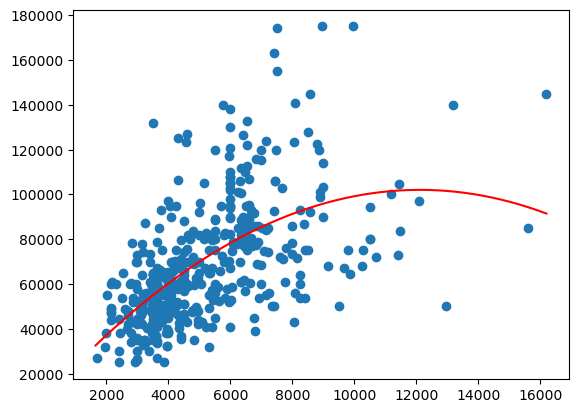

In [9]:
values = np.linspace(X_full.min(), X_full.max(), 50)

# (1) Learn model parameters
weights = train(X_train, y_train, 2)

# (2) Evaluate model
predicted_values = predict(values, weights, 2)
#print(predicted_values)

# (3) Plot predicted values
plt.scatter(X_train, y_train)
plt.plot(values, predicted_values, color='red')


---
**Task 5 (medium): Order of Polynomial👩‍💻**
In this task you will experiment with the order of the polynomial model to investigate performance.
1. Increase the order of the polynomial, identify the kernel and evaluate the results for:    1. A $3$rd-order polynomial.
    2. A $4$th-order polynomial.
    3. A $7$th-order polynomial.
    4. An $11$th-order polynomial.



Observe that the predictions deviate drastically from the actual lot sizes for the $7$th-order polynomial and above. 
1. Explain why this happens? 


---

### Answer: 

The predictions deviate drastically from the actual lot sizes for 7th and 11th order polynomial because of overfitting, the plot tries to go through every single point. The model learns too much from the input data (variance), minimizes training error but it does not generalize well to unseen data. High degree terms (like x^7 or x^11) can give some weird values when multiplied with the weights i think??
The model has low bias (because it fits the training data well), but high variance (it won’t generalize to new data).

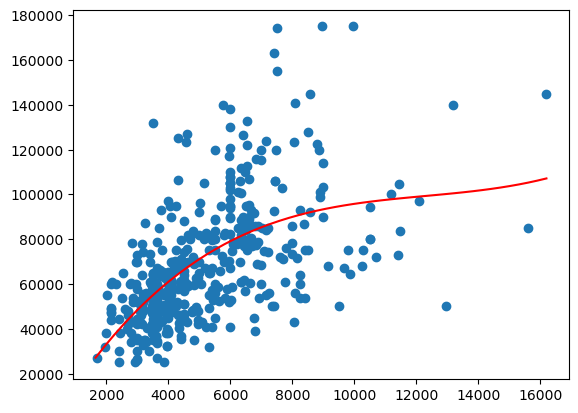

In [10]:
# 3rd order:
# (1) Learn model parameters
weights = train(X_train, y_train, 3)

# (2) Evaluate model
predicted_values = predict(values, weights, 3)

# (3) Plot predicted values
plt.scatter(X_train, y_train)
plt.plot(values, predicted_values, color='red')

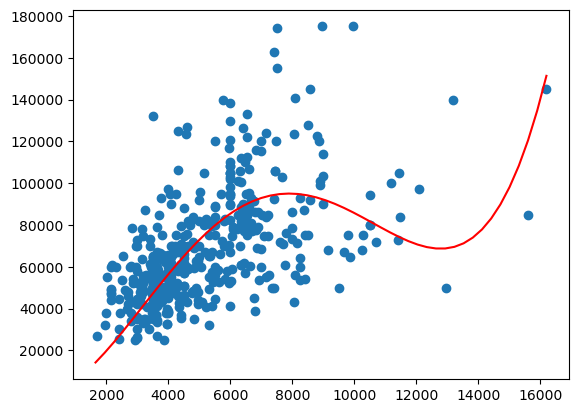

In [11]:

# 4th order:
# (1) Learn model parameters
weights = train(X_train, y_train, 4)

# (2) Evaluate model
predicted_values = predict(values, weights, 4)
#print(predicted_values)

# (3) Plot predicted values
plt.scatter(X_train, y_train)
plt.plot(values, predicted_values, color='red')

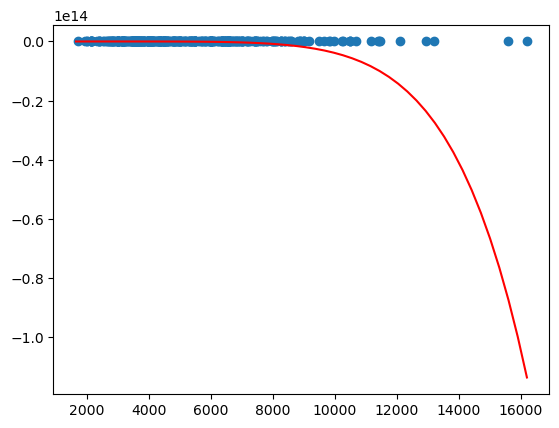

In [12]:

# 7th order:
# (1) Learn model parameters
weights = train(X_train, y_train, 7)

# (2) Evaluate model
predicted_values = predict(values, weights, 7)
#print(predicted_values)

# (3) Plot predicted values
plt.scatter(X_train, y_train)
plt.plot(values, predicted_values, color='red')

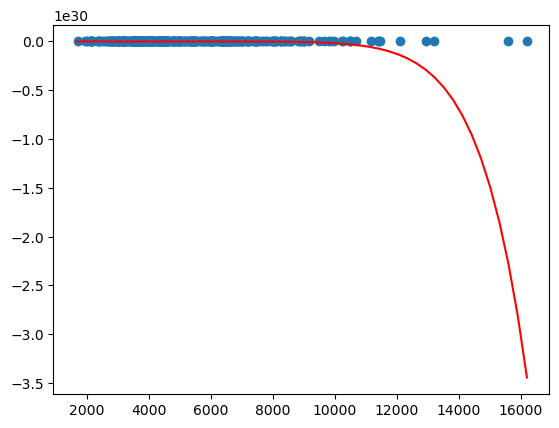

In [13]:
# 11th order:
# (1) Learn model parameters
weights = train(X_train, y_train, 11)

# (2) Evaluate model
predicted_values = predict(values, weights, 11)
#print(predicted_values)

# (3) Plot predicted values
plt.scatter(X_train, y_train)
plt.plot(values, predicted_values, color='red')

This problem can be solved by normalizing the input vectors. Normalization transforms the input values to the interval $[0, 1]$ by scaling and translating the inputs using the minimum and maximum values.
The cell below provides functions for normalizing and denormalizing (the inverse transformation) input vectors:


In [14]:
def normalized(X):
    n = (X - np.min(X_full))/np.max(X_full)
    return n

def denormalized(X):
    return X*np.max(X_full) + np.min(X_full)


---
**Task 6 (medium):  Higher order polynomials with normalization👩‍💻**
In this task you will redo [Task 4](#learn) using normalization. Write your solution in the cell below.
1. Normalize the inputs in the variable `X_{train}`
 using the function`normalized`
. 
2. Re-train the model parameters using the normalized inputs using $3$rd, $4$th, and $7$th order polynomials as in [Task 4](#learn).
3. Predict the values of (normalized) `X_{test}`
.
4. Plot the predicted result as a curve using `plt.plot`



---

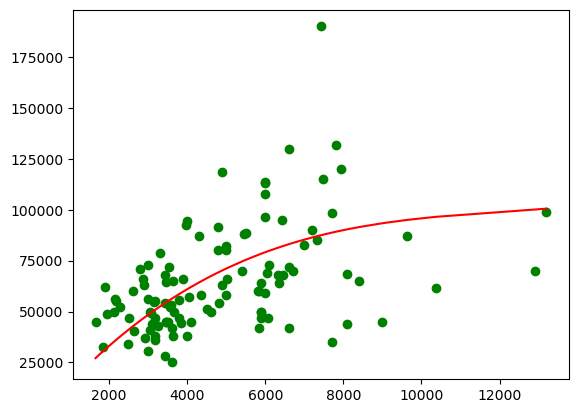

In [15]:
# (1) Normalize the inputs
normalized_x_train = normalized(X_train)

# (2) Learn parameters and predict y-values
weights = train(normalized_x_train, y_train, 3)

normalized_x_test = normalized(X_test)

y_predicted = predict(normalized_x_test, weights, 3)

# Sort X_test and corresponding y_predicted for a smooth plot
sorted_indices = np.argsort(X_test)
X_test_sorted = X_test[sorted_indices]
y_predicted_sorted = y_predicted[sorted_indices]

# (3) Plot predicted values
plt.scatter(X_test, y_test, c="g")
plt.plot(X_test_sorted, y_predicted_sorted, "r")  # Sorted for a clean plot
plt.show()

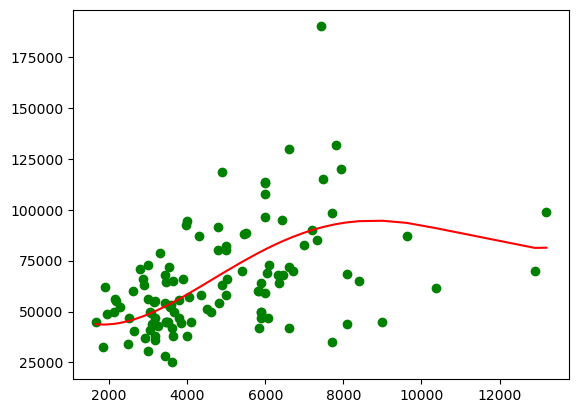

In [16]:
# (1) Normalize the inputs
normalized_x_train = normalized(X_train)

# (2) Learn parameters and predict y-values
weights = train(normalized_x_train, y_train, 4)

normalized_x_test = normalized(X_test)

y_predicted = predict(normalized_x_test, weights, 4)

# Sort X_test and corresponding y_predicted for a smooth plot
sorted_indices = np.argsort(X_test)
X_test_sorted = X_test[sorted_indices]
y_predicted_sorted = y_predicted[sorted_indices]

# (3) Plot predicted values
plt.scatter(X_test, y_test, c="g")
plt.plot(X_test_sorted, y_predicted_sorted, "r")  # Sorted for a clean plot
plt.show()

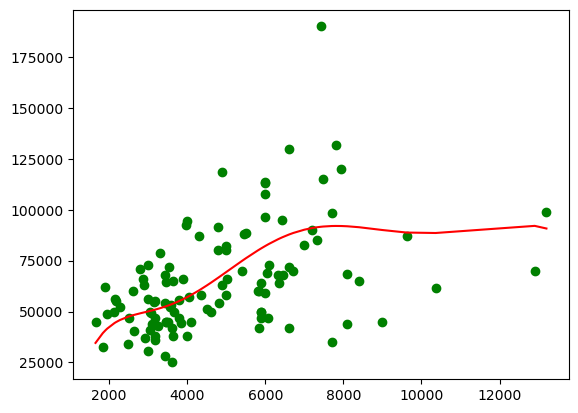

In [17]:
# (1) Normalize the inputs
normalized_x_train = normalized(X_train)

# (2) Learn parameters and predict y-values
weights = train(normalized_x_train, y_train, 7)

normalized_x_test = normalized(X_test)

y_predicted = predict(normalized_x_test, weights, 7)

# Sort X_test and corresponding y_predicted for a smooth plot
sorted_indices = np.argsort(X_test)
X_test_sorted = X_test[sorted_indices]
y_predicted_sorted = y_predicted[sorted_indices]

# (3) Plot predicted values
plt.scatter(X_test, y_test, c="g")
plt.plot(X_test_sorted, y_predicted_sorted, "r")  # Sorted for a clean plot
plt.show()


---
**Task 7 (medium): Normalization improvement💡**
1. Visually inspect and reason about how normalization impacts the results.
2. Explain why normalization achieves a better performance.


---

### Answer:
1. Normalization seems to make the predictions more accurate. 
2. Normalization achieves a better performance, because finding the weights of a model works best when the x-values don't fluctuate too much in their size as the order increases. So before normalization, if the value of x is around 16.000, then the maximum value of x in a model of 7th order would be something around 16.000^7 (very large feature values!). This can skew the calculated weights, so that they become very small, which doesn't generalize well to other data. By normalizing the data, we ensure that all x-values are within 0 and 1, and therefore there are limits to how large the features can become when we take them to fx the power of 7. 


## Evaluation
In the following steps you will evaluate the models using the _root mean squarred error_ (RMSE) on unseen data (test data). 
The _root mean squared error_ is defined as:

$$
 \sqrt{\frac{1}{m}\sum_{i=1}^{m}(f_{\mathbf{w}}(x_{i})-y_{i})^2}
$$

and calculates the average error measured in the same units as the house prices. 
The code cell below provides an implementation of the RMSE:


In [18]:
def rmse(X, y, w, order):
    X = normalized(X)
    ym = predict(X, w, order)
    return np.sqrt(np.mean((y-ym)**2))


---
**Task 8 (easy): Model evaluation👩‍💻**
In this task you will implement the function `evaluate_models`
 to evaluate polynomial models of order 1 to 19 using the _root mean squared error_. 
For each model order:
1. Learn the model parameters using the `train`
 function.
2. Calculate the _root mean squared error_ of the model on the training set.
3. Calculate the _root mean squared error_ of the model on the test set.


---

In [19]:
def evaluate_models():
    """Calculates the RMS error for both training and test data for models with polynomial orders
    from 1 to 19.
    
    Returns: (train losses, test losses)
    """
    losses_train = []
    losses_test = []
    for order in range(1, 19):
        # (1) Normalize the inputs
        normalized_x_train = normalized(X_train)

        # (2) Learn parameters
        weights = train(normalized_x_train, y_train, order)

        rmse_train = rmse(X_train, y_train, weights, order)
        rmse_test = rmse(X_test, y_test, weights, order)

        losses_train.append(rmse_train)
        losses_test.append(rmse_test)
    return losses_train, losses_test


---
**Task 9 (easy): Plotting results👩‍💻**
1. Plot the training and test losses in the cell below. 
2. Explain why the test and training losses behave differently as the order of the polynomial increases.
3. Use RMSE and the plot(s) to argue what could be the consequences of using these models given that they have these properties. 


---

### Answer:
The test and training losses behave differently due to overfitting. The training losses decrease as the order grows, because the model becomes overfitted, meaning that it tries to fit the real patterns AND also all the noise and random fluctuations in the data. So it can be very precise on the training data, but an overfitted model does not generalize well to unseen data. This is why we see that the test losses actually increase, because the model cannot predict unseen data very well when it is to tightly coupled with the training data. 

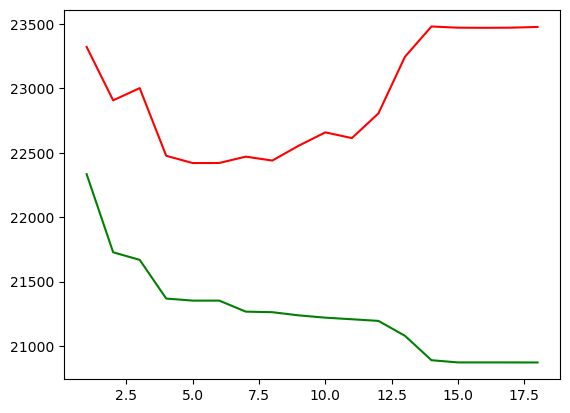

In [22]:
# Write your solution here
losses_train, losses_test = evaluate_models()
model_orders = np.linspace(1, 18, 18)
plt.plot(model_orders, losses_train, "g") # Green is train
plt.plot(model_orders, losses_test, "r") # Red is test


---
**Task 10 (medium): Reflection💡**
1. Reflect on whether it's possible and reasonable to chose a higher order polynomial for improving the training loss. Use the plot in your argumentation. 


---

# Write your answers here
I don't think the main goal should be improving training loss, because as we see from the plot above, low training loss means that it negatively impacts the test loss. We need to find the "sweet spot" where both training loss and test loss are as low as possible. So it is possible to choose a higher order polynomial for improving traning loss, but it is not always reasonable because low training loss might mean an overfitted model which is not very useful when we later want to use it to predict some unseen data. 